In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from random import randint,random

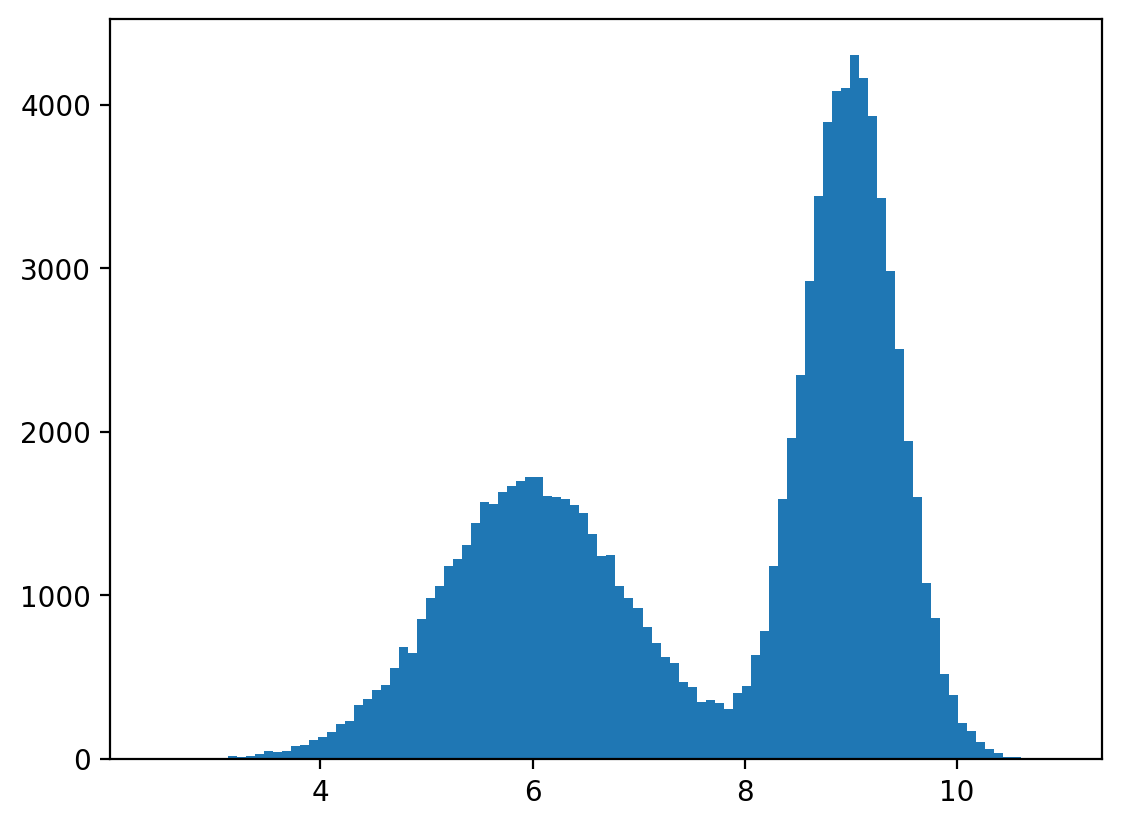

In [56]:
mu = [randint(0,10) for i in range(3)]
sigma = [randint(1,5)*random() for i in range(3)]
p = [random() for i in range(5)]
p[2] = 1 - p[0] - p[1]

N = 100000
echantillon_norm = [norm(mu[i], sigma[i]).rvs(N) for i in range(3)]
echantillon = [echantillon_norm[random()>p[0] + random()>p[1]][randint(0,N-1)] for i in range(N)]

plt.hist(echantillon, bins = 100)
plt.show()

In [57]:
F = 3

In [62]:
def EM_algorithm_step(pi, theta, x, n, F):
  new_rho = np.zeros((n,F))
  s = np.zeros(n)
  p = np.zeros((n,F))
  for i in range(n):
    for y in range(F):
      p[i,y] = 1/np.sqrt(2*np.pi*theta[y,1])*np.exp(-(x[i]-theta[y,0])**2/(2*theta[y,1]))
      s[i]+=pi[y]*p[i,y]
  for i in range(n):
    for y in range(F):
      new_rho[i,y] = pi[y]*p[i,y]/s[i]
  for y in range(F):
    new_pi=0
    for i in range(n):
      new_pi += new_rho[i,y]/n
    pi[y] = new_pi
  for y in range(F):
    s1 = 0
    for i in range(n):
      s1 += new_rho[i,y]*x[i]
    theta[y,0] = s1/(n*pi[y])
    s2 = 0
    for i in range(n):
      s2 += new_rho[i,y]*(x[i] - theta[y,0])**2
    theta[y,1] = s2/(n*pi[y])
    return pi, theta

def EM_algorithm(n: int, F: int, x: np.array, pi0: np.array, theta0: np.array):
  pi, theta = pi0, theta0
  liste_pi, liste_theta = [pi], [theta]
  j=0
  while j<10:
    pi, theta = EM_algorithm_step(pi, theta, x, n, F)
    liste_pi.append(pi)
    liste_theta.append(theta)
    j += 1
  return pi, theta, liste_pi, liste_theta


In [63]:
indices = np.arange(N)
np.random.shuffle(indices)
echantillon_shuffled = []
for i in indices:
  echantillon_shuffled.append(echantillon[i])
pi0 = np.zeros(F)
theta0 = np.zeros((F,2))
for y in range(F):
  pi0[y] = 1/F

for y in range(F):
  theta0[y,0] += np.mean(echantillon_shuffled[y*N//F : (y+1)*N//F])
  for i in range(y*N//F, (y+1)*N//F):
    theta0[y,1] += 1/N*(echantillon_shuffled[i]-theta0[y,0])**2
pi, theta, liste_pi, liste_theta = EM_algorithm(N, F, echantillon, pi0, theta0)
print( "pi = ", pi)
print(" theta = ", theta)

pi =  [9.99999996e-01 2.41174515e-09 1.41479376e-09]
 theta =  [[7.67114985 2.66947813]
 [7.6820516  0.88928903]
 [7.67080502 0.88626546]]


In [66]:
import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'


In [65]:
@widgets.interact(etape=widgets.IntSlider(0, min=1, max=len(liste_pi),
                                              description="Etape"))

def progression(etape=0):
  x = np.linspace(min(echantillon), max(echantillon), 200)
  nb, _, _ = plt.hist(echantillon, bins = 100)
  for i in range(F):
      plt.plot(x, norm(liste_theta[etape-1][i][0],liste_theta[etape-1][i][1]).pdf(x)*liste_pi[etape-1][i]*max(nb)*np.sqrt(2*np.pi))
  plt.show()

interactive(children=(IntSlider(value=1, description='Etape', max=101, min=1), Output()), _dom_classes=('widge…